# Otimização — capítulo 3: os sete métodos no mesmo problema

Notebook de apoio (Python) à comparação final do capítulo 3. Reproduz, com implementações didáticas equivalentes às funções MATLAB dos slides, a tabela e a figura *Os sete métodos no mesmo problema, com o custo em avaliações*.

Regras da comparação (folha de convenções da UC):
* mesmo problema (Rosenbrock), mesmo ponto inicial $\mathbf{x}_0=(-1{,}5;\,2)$, mesmo critério (primeira avaliação, ou iterando, com $f<10^{-4}$);
* custo em **avaliações**, contadas à parte: $n_f$, $n_g$, $n_H$; equivalente em $f$ com diferenças centrais ($n=2$): $n_f+4n_g+4n_H$;
* método estocástico (pesquisa aleatória localizada): 30 corridas, sementes $0$–$29$, mediana e quartis.

Frase a reter: *neste problema, com estes parâmetros* — não há vencedor em abstrato.

In [1]:
"""Notebook de apoio ao cap. 3 — comparação transversal do cap. 3 — os sete métodos no mesmo problema, com o mesmo ponto inicial,
o mesmo critério e o custo contado em avaliações (n_f, n_g, n_H separados).

Problema: Rosenbrock, x0 = (-1,5; 2). Critério comum: primeira avaliação com f < 1e-4 (f nos iterandos dos métodos de 3.3 também é contada).
Pesquisa em linha dos métodos de 3.3: Brent com bracket, tol 1e-10 (line_search com exact=True, a indicada no slide).
Pesquisa aleatória localizada: estocástica -> 30 corridas, mediana e quartis.
"""
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

RED = "#BE1E2D"; GREY = "#323232"; BLUE = "#1f5fa8"; LIGHT = "#f2c4c8"; GREEN = "#3a7d44"
plt.rcParams.update({"font.size": 10, "axes.edgecolor": GREY, "text.color": GREY,
                     "axes.labelcolor": GREY, "xtick.color": GREY, "ytick.color": GREY,
                     "mathtext.fontset": "cm"})

rosen = lambda x: (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2
grosen = lambda x: np.array([-2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2), 200 * (x[1] - x[0]**2)])
Hrosen = lambda x: np.array([[2 - 400 * (x[1] - 3 * x[0]**2), -400 * x[0]], [-400 * x[0], 200]])
X0 = np.array([-1.5, 2.0])
FTOL = 1e-4


class Counter:
    """Conta n_f, n_g, n_H e regista, para cada avaliação de f, o custo acumulado equivalente em f."""
    def __init__(self, f, g=None, H=None, n=2):
        self.f, self.g, self.H = f, g, H
        self.nf = self.ng = self.nH = 0
        self.trace = []          # (n_f, n_g, n_H, f) em cada avaliação de f
        self.n = n

    def F(self, x):
        v = self.f(x); self.nf += 1; self.trace.append((self.nf, self.ng, self.nH, v)); return v

    def G(self, x):
        self.ng += 1; return self.g(x)

    def Hs(self, x):
        self.nH += 1; return self.H(x)

    def record(self, x):
        """avalia f no iterando para o criterio de comparacao e CONTA essa avaliacao
        (regra da UC: contar todas as avaliacoes feitas, incluindo f nos iterandos dos metodos com derivadas)"""
        return self.F(x)

    def first_below(self, tol):
        """primeira avaliação de f com f < tol: devolve (n_f, n_g, n_H) nesse instante."""
        for nf, ng, nH, v in self.trace:
            if v < tol:
                return nf, ng, nH
        return None


def equiv(nf, ng, nH, n=2):
    """custo equivalente em avaliações de f se as derivadas fossem por diferenças centrais:
    gradiente 2n; Hessiana completa 2n^2+1 pontos, que reaproveita os 2n do gradiente e f(x_k)
    (f(x_k) já está em n_f, porque f nos iterandos conta) -> cada Hessiana acrescenta 2n^2-2n (n=2: 4)."""
    return nf + 2 * n * ng + (2 * n * n - 2 * n) * nH

## Pesquisa em linha
A usada nas figuras de 3.3 (`exact=True`, Brent com *bracket*) e a do MATLAB dos slides (`fminbnd` limitado com alargamento). Nota: FR é o método mais sensível a esta escolha.

In [2]:
def line_search(F, x, d, exact=True):
    """exact=True: Brent com bracket, tol 1e-10 (a usada nas figuras de 3.3);
    exact=False: fminbnd-like em [0,b] com alargamento (a do MATLAB dos decks)."""
    phi = lambda t: F(x + t * d)
    if exact:
        r = minimize_scalar(phi, bracket=(0, 1e-3), method="brent", tol=1e-10)
        return max(r.x, 0.0)
    b = 1.0; r = minimize_scalar(phi, bounds=(0, b), method="bounded", options={"xatol": 1e-5}); alpha = r.x
    while alpha > 0.99 * b:            # minimo no extremo: alargar o intervalo
        b = 10 * b; alpha = minimize_scalar(phi, bounds=(0, b), method="bounded", options={"xatol": 1e-5}).x
    return alpha

## 3.2 — métodos sem derivadas

In [3]:
def nelder_mead(F, S, tolx=1e-8, tolf=1e-10, kmax=1000):
    S = [np.array(s, float) for s in S]; Fv = [F(s) for s in S]; n = len(S) - 1
    for k in range(kmax):
        idx = np.argsort(Fv); S = [S[i] for i in idx]; Fv = [Fv[i] for i in idx]
        if Fv[-1] - Fv[0] <= tolf and max(np.linalg.norm(s - S[0]) for s in S) <= tolx: break
        xc = np.mean(S[:-1], axis=0); xw = S[-1]
        xr = xc + (xc - xw); fr = F(xr)
        if fr < Fv[0]:
            xe = xc + 2 * (xc - xw); fe = F(xe)
            S[-1], Fv[-1] = (xe, fe) if fe < fr else (xr, fr)
        elif fr < Fv[-2]:
            S[-1], Fv[-1] = xr, fr
        else:
            xk = xc + 0.5 * (xc - xw) if fr < Fv[-1] else xc - 0.5 * (xc - xw); fk = F(xk)
            if fk < min(fr, Fv[-1]): S[-1], Fv[-1] = xk, fk
            else:
                S = [S[0]] + [S[0] + 0.5 * (s - S[0]) for s in S[1:]]; Fv = [Fv[0]] + [F(s) for s in S[1:]]
    return S[0], Fv[0], k


def box_evo(F, x0, delta, eps=1e-6, kmax=10000):
    x = np.array(x0, float); fx = F(x); n = len(x); delta = np.array(delta, float)
    S = np.array([[1 if (i >> j) & 1 else -1 for j in range(n)] for i in range(2**n)], float)
    for k in range(kmax):
        if np.linalg.norm(delta) < eps: break
        V = x + 0.5 * S * delta; Fv = [F(v) for v in V]; i = int(np.argmin(Fv))
        if Fv[i] < fx: x, fx = V[i], Fv[i]
        else: delta = delta / 2
    return x, fx, k


def exploratory(F, x0, P, f0):
    """Exploração de Deb (2012): avalia +P_j e -P_j e fica com o melhor dos três."""
    x1 = x0.copy(); f1 = f0
    for j in range(len(x0)):
        tp = x1.copy(); tp[j] += P[j]; fp = F(tp)
        tm = x1.copy(); tm[j] -= P[j]; fm = F(tm)
        if fp < f1 and fp <= fm: x1, f1 = tp, fp
        elif fm < f1: x1, f1 = tm, fm
    return x1, f1


def hooke_jeeves(F, x0, P0, T, a=2.0, kmax=100000):
    xb = np.array(x0, float); fb = F(xb); P = np.array(P0, float); T = np.array(T, float)
    for k in range(kmax):
        xe, fe = exploratory(F, xb, P, fb)
        if fe >= fb:
            P = P / 2
            if np.all(P < T): break
            continue
        while True:
            xt = xb + a * (xe - xb); ft = F(xt)
            xn, fn = exploratory(F, xt, P, ft)
            if fn >= fe: xb, fb = xe, fe; break
            xb, fb, xe, fe = xe, fe, xn, fn
    return xb, fb, k


def local_random_search(F, x0, r, m, gamma, tol, kmax, rng):
    x = np.array(x0, float); fx = F(x); n = len(x)
    for k in range(kmax):
        C = x + r * (2 * rng.random((m, n)) - 1); v = [F(c) for c in C]; i = int(np.argmin(v))
        if v[i] < fx: x, fx = C[i], v[i]
        else: r = gamma * r
        if r <= tol: break
    return x, fx, k

## 3.3 — métodos com derivadas
Em cada iterando chama-se `C.record(x)`, que avalia $f$ no iterando para aplicar o critério comum e **conta** essa avaliação em $n_f$ (é uma avaliação feita; sem ela, o Newton puro "decidiria" por $f$ com $n_f=0$).

In [4]:
def steepest(C, x0, tolg=1e-8, kmax=3000):
    x = np.array(x0, float); C.record(x)
    for k in range(kmax):
        g = C.G(x)
        if np.linalg.norm(g) <= tolg: break
        d = -g; t = line_search(C.F, x, d); xn = x + t * d
        x = xn; C.record(x)
    return x, C.f(x), k      # valor final: já avaliado (e contado) em C.record


def newton(C, x0, tolg=1e-8, kmax=200, damped=True):
    x = np.array(x0, float); C.record(x)
    for k in range(kmax):
        g = C.G(x)
        if np.linalg.norm(g) <= tolg: break
        H = C.Hs(x)
        if damped:                      # regularizar H, garantir descida, pesquisa em linha
            mu = 1e-3 * max(1, np.linalg.norm(H))
            while np.any(np.linalg.eigvalsh(H) <= 0): H = H + mu * np.eye(len(x)); mu *= 10
            d = -np.linalg.solve(H, g)
            if g @ d >= 0: d = -g
            t = line_search(C.F, x, d)
        else:                           # Newton puro: sem salvaguardas
            d = -np.linalg.solve(H, g); t = 1.0
        x = x + t * d; C.record(x)
    return x, C.f(x), k      # valor final: já avaliado (e contado) em C.record


def cg_fr(C, x0, tolg=1e-8, kmax=3000, restart=2):
    x = np.array(x0, float); n = len(x); C.record(x); g = C.G(x); d = -g
    for k in range(kmax):
        if np.linalg.norm(g) <= tolg: break
        t = line_search(C.F, x, d); x = x + t * d; C.record(x); gn = C.G(x)
        beta = (gn @ gn) / (g @ g)
        if restart and (k + 1) % restart == 0: beta = 0.0
        dn = -gn + beta * d
        if gn @ dn >= 0: dn = -gn
        g, d = gn, dn
    return x, C.f(x), k      # valor final: já avaliado (e contado) em C.record

## Corridas, tabela e figura

Nelder--Mead                                  n_f=   166 n_g=    0 n_H=   0 equiv=   166  (total corrido 263,0,0)
Box ($\Delta_0=1$)                            n_f= 13445 n_g=    0 n_H=   0 equiv= 13445  (total corrido 25897,0,0)
Hooke--Jeeves ($P_0=0{,}5$)                   n_f=   430 n_g=    0 n_H=   0 equiv=   430  (total corrido 662,0,0)


Gradiente nao atingiu 60900 3000 0 0.00024314486459865473
Gradientes conjugados (FR, reinício $n$)      n_f=   718 n_g=   34 n_H=   0 equiv=   854  (total corrido 793,38,0)
Newton puro                                   n_f=     6 n_g=    5 n_H=   5 equiv=    46  (total corrido 8,8,7)
Newton amortecido                             n_f=   281 n_g=   12 n_H=  12 equiv=   377  (total corrido 357,15,14)
pesquisa aleatoria localizada: mediana 975, quartis 867-1052, falhas 0/30


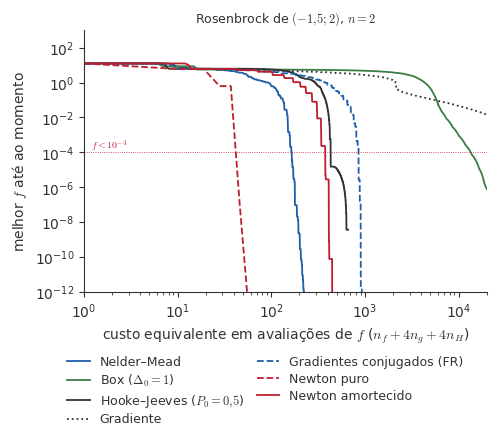

Pesquisa aleatória localizada$^\dagger$ & 0 & 975 [867; 1052] & -- & -- & 975 \\
Nelder--Mead & 0 & 166 & -- & -- & 166 \\
Box ($\Delta_0=1$) & 0 & 13445 & -- & -- & 13445 \\
Hooke--Jeeves ($P_0=0{,}5$) & 0 & 430 & -- & -- & 430 \\
Gradiente$^\ddagger$ & 1 & 60900 & 3000 & -- & 72900 \\
Gradientes conjugados (FR, reinício $n$) & 1 & 718 & 34 & -- & 854 \\
Newton puro & 2 & 6 & 5 & 5 & 46 \\
Newton amortecido & 2 & 281 & 12 & 12 & 377 \\



In [5]:
rows = []
runs = [
    ("Nelder--Mead", 0, lambda C: nelder_mead(C.F, [X0, X0 + [0.5, 0], X0 + [0, 0.5]])),
    ("Box ($\\Delta_0=1$)", 0, lambda C: box_evo(C.F, X0, [1, 1])),
    ("Hooke--Jeeves ($P_0=0{,}5$)", 0, lambda C: hooke_jeeves(C.F, X0, [0.5, 0.5], [1e-6, 1e-6])),
    ("Gradiente", 1, lambda C: steepest(C, X0)),
    ("Gradientes conjugados (FR, reinício $n$)", 1, lambda C: cg_fr(C, X0)),
    ("Newton puro", 2, lambda C: newton(C, X0, damped=False)),
    ("Newton amortecido", 2, lambda C: newton(C, X0, damped=True)),
]
traces = {}
for name, order, run in runs:
    C = Counter(rosen, grosen, Hrosen)
    try:
        run(C)
    except Exception as e:
        print(name, "erro", e)
    hit = C.first_below(FTOL)
    traces[name] = C.trace
    if hit is None:
        rows.append((name, order, None, None, None, None, C.nf, C.ng, C.nH)); print(name, "nao atingiu", C.nf, C.ng, C.nH, min(t[3] for t in C.trace))
    else:
        nf, ng, nH = hit
        rows.append((name, order, nf, ng, nH, equiv(nf, ng, nH), C.nf, C.ng, C.nH))
        print(f"{name:45s} n_f={nf:6d} n_g={ng:5d} n_H={nH:4d} equiv={equiv(nf, ng, nH):6d}  (total corrido {C.nf},{C.ng},{C.nH})")

# pesquisa aleatoria localizada: 30 corridas
lr = []
for s in range(30):
    rng = np.random.default_rng(s); C = Counter(rosen)
    local_random_search(C.F, X0, 1.0, 20, 0.9, 1e-8, 5000, rng)
    hit = C.first_below(FTOL); lr.append(hit[0] if hit else np.inf)
lr = np.array(lr); q1, med, q3 = np.percentile(lr[np.isfinite(lr)], [25, 50, 75]); nfail = int(np.sum(~np.isfinite(lr)))
print(f"pesquisa aleatoria localizada: mediana {med:.0f}, quartis {q1:.0f}-{q3:.0f}, falhas {nfail}/30")

# tabela LaTeX
import io
fh = io.StringIO()
if True:
    fh.write(f"Pesquisa aleatória localizada$^\\dagger$ & 0 & {med:.0f} [{q1:.0f}; {q3:.0f}] & -- & -- & {med:.0f} \\\\\n")
    for name, order, nf, ng, nH, eq, tnf, tng, tnH in rows:
        if nf is None:
            fh.write(f"{name}$^\\ddagger$ & {order} & {tnf} & {tng} & -- & {equiv(tnf, tng, 0)} \\\\\n")
        else:
            fh.write(f"{name} & {order} & {nf} & {ng if ng else '--'} & {nH if nH else '--'} & {eq} \\\\\n")

# figura: f vs custo equivalente em f
fig, ax = plt.subplots(figsize=(5.2, 3.4))
styles = {"Nelder--Mead": (BLUE, "-"), "Box ($\\Delta_0=1$)": (GREEN, "-"), "Hooke--Jeeves ($P_0=0{,}5$)": (GREY, "-"),
          "Gradiente": (GREY, ":"), "Newton amortecido": (RED, "-"), "Newton puro": (RED, "--"),
          "Gradientes conjugados (FR, reinício $n$)": (BLUE, "--")}
for name, tr in traces.items():
    xs = [equiv(nf, ng, nH) for nf, ng, nH, v in tr]; ys = np.minimum.accumulate([max(v, 1e-16) for *_, v in tr])
    c, ls = styles[name]; ax.semilogy(xs, ys, color=c, ls=ls, lw=1.3, label=name.replace("(FR, reinício $n$)", "(FR)").replace("--", "–"))
ax.axhline(FTOL, color=RED, lw=0.6, ls=":"); ax.text(1.2, 1.6e-4, "$f<10^{-4}$", color=RED, fontsize=7)
ax.set_xscale("log"); ax.set_xlim(1, 2e4); ax.set_ylim(1e-12, 1e3)
ax.set_xlabel("custo equivalente em avaliações de $f$ ($n_f+4n_g+4n_H$)"); ax.set_ylabel("melhor $f$ até ao momento")
ax.legend(fontsize=9, frameon=False, loc="upper center", bbox_to_anchor=(0.45, -0.2), ncol=2,
          handlelength=1.8, columnspacing=1.0, labelspacing=0.3); ax.set_title("Rosenbrock de $(-1{,}5;2)$, $n=2$", fontsize=9)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.show()

print(fh.getvalue())

## O mesmo com o SciPy

`scipy.optimize.minimize` devolve os contadores já feitos (`r.nfev`, `r.njev`, `r.nhev`): o critério de paragem e a pesquisa em linha são os do SciPy, por isso os números não coincidem com os de cima — a *ideia* da comparação é a mesma.

In [6]:
from scipy.optimize import minimize
for method, kw in (("Nelder-Mead", {}), ("CG", {"jac": grosen}), ("BFGS", {"jac": grosen}), ("Newton-CG", {"jac": grosen, "hess": Hrosen})):
    r = minimize(rosen, X0, method=method, tol=1e-8, **kw)
    print(f"{method:12s} f={r.fun:.2e}  nfev={r.nfev:4d}  njev={getattr(r, 'njev', 0):4d}  nhev={getattr(r, 'nhev', 0):4d}")

Nelder-Mead  f=2.32e-18  nfev= 237  njev=   0  nhev=   0
CG           f=8.54e-25  nfev=  81  njev=  79  nhev=   0
BFGS         f=9.23e-23  nfev=  45  njev=  45  nhev=   0
Newton-CG    f=6.59e-23  nfev= 211  njev= 211  nhev= 193
